In [5]:
# librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Cargamos el dataset especificando la columna de fecha
df = pd.read_csv('sample_trans.csv')

## Análisis Exploratorio de Datos (EDA)

In [7]:
# Celda provisional para conocer la estructura del dataset
print("--- Columnas y tipos de datos ---")
print(df.dtypes)
print("\n--- Primeros 5 registros ---")
df.head()

--- Columnas y tipos de datos ---
fecha_de_transaccion     object
canal_de_compra          object
division                 object
sku_producto             object
cliente_unico_id         object
orden_de_venta           object
monto_bruto             float64
monto_neto              float64
dtype: object

--- Primeros 5 registros ---


,fecha_de_transaccion,canal_de_compra,division,sku_producto,cliente_unico_id,orden_de_venta,monto_bruto,monto_neto
0,7/30/2025 12:00:00 AM,Palacio de Hierro,JUGUETERIA,43828158,19c749a2322a9e0da8f648321c67f773,20250730_1013_342_5857,359.00,359.00
1,11/18/2024 12:00:00 AM,Palacio de Hierro,GOURMET,43814414,c490f3d2f25766657ffb0e756508786e,20241118_1009_421_756,587.00,587.00
2,9/3/2024 12:00:00 AM,E Commerce,DAMAS,43776264,e38923d6ba9d0402b4b0f67c550e54c8,Sites-palacio-MX-Site.5008756547,2190.00,1888.00
3,2/1/2025 12:00:00 AM,E Commerce,TECNOLOGIA,44115898,93ff5ba6316cb5cd8605f56b99c93b01,Sites-palacio-MX-Site.1010194069,13166.37,11350.32
4,12/29/2024 12:00:00 AM,Palacio de Hierro,DAMAS,43825319,3bc936faa076db40a2cbc5d2ffb8861e,20241229_1005_185_6514.0,3114.00,3114.00


### Configuración Inicial

In [8]:
# Configuración estética para las gráficas de la historia
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 11, 'axes.titlesize': 13})

# Carga del dataset original
df = pd.read_csv('sample_trans.csv')

# Conversión explícita de la columna temporal
df['fecha_de_transaccion'] = pd.to_datetime(df['fecha_de_transaccion'])

print(f"Dataset cargado con éxito. Total de registros transaccionales: {df.shape[0]:,}")

/var/folders/8v/p10964lx7y786kktss6jf6wc0000gn/T/ipykernel_5795/2138004115.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['fecha_de_transaccion'] = pd.to_datetime(df['fecha_de_transaccion'])


Dataset cargado con éxito. Total de registros transaccionales: 4,101,885


In [9]:
# 1. Diagnóstico de Valores Nulos
print("==================================================")
print("          DIAGNÓSTICO DE VALORES NULOS            ")
print("==================================================")
print(df.isnull().sum())

# 2. Análisis preliminar de Montos Negativos o en Cero
negativos_neto = df[df['monto_neto'] < 0].shape[0]
cero_neto = df[df['monto_neto'] == 0].shape[0]

print("\n==================================================")
print("     ANÁLISIS DE MONTOS NETOS ANÓMALOS            ")
print("==================================================")
print(f"Transacciones con monto neto MENOR a cero (Negativos): {negativos_neto,}")
print(f"Transacciones con monto neto IGUAL a cero: {cero_neto,}")

# 3. Detección de Outliers Extremos en el monto bruto
print("\n==================================================")
print("          OUTLIERS EXTREMOS (TOP 5 MONTOS)        ")
print("==================================================")
print(df.sort_values(by='monto_neto', ascending=False)[['cliente_unico_id', 'monto_bruto', 'monto_neto']].head(5))

          DIAGNÓSTICO DE VALORES NULOS            
fecha_de_transaccion        0
canal_de_compra          1019
division                64038
sku_producto                0
cliente_unico_id            0
orden_de_venta              0
monto_bruto                 0
monto_neto                  0
dtype: int64

     ANÁLISIS DE MONTOS NETOS ANÓMALOS            
Transacciones con monto neto MENOR a cero (Negativos): (73698,)
Transacciones con monto neto IGUAL a cero: (104902,)

          OUTLIERS EXTREMOS (TOP 5 MONTOS)        
                         cliente_unico_id  monto_bruto  monto_neto
2016061  257c8d1c688ff411e943897d7e507048    7350000.0   7350000.0
1873099  ecc7ce31b24fddf7f51d73611d1f989d    5950000.0   5950000.0
1938623  a24a44f2a345eec9c82d4659dcf4cea9    4694000.0   4694000.0
3510497  f8eb70d110acd24790dc15102669804b    4656000.0   4656000.0
777069   4928d8fc2e852d228f6392d7e80a89cd    4240000.0   4240000.0


In [10]:
# ==============================================================================
# TRATAMIENTO DE CALIDAD DE DATOS (Nulos, Negativos y Fechas)
# ==============================================================================

# 1. Tratamiento de Nulos: Imputación con categoría explícita para evitar pérdida de registros
df['canal_de_compra'] = df['canal_de_compra'].fillna('NO ESPECIFICADO')
df['division'] = df['division'].fillna('NO ESPECIFICADA')

# 2. Documentación y separación de registros para análisis de comportamiento de negocio
# Guardamos los negativos y ceros en un dataframe aparte para no alterar el flujo transaccional limpio si es necesario
df_Devoluciones = df[df['monto_neto'] < 0].copy()
df_Ceros = df[df['monto_neto'] == 0].copy()

# Nos quedamos temporalmente con la actividad comercial con valor monetario positivo para analizar el flujo
df_limpio = df[df['monto_neto'] > 0].copy()

print("==================================================")
print("          PROCESAMIENTO DE CALIDAD COMPLETADO     ")
print("==================================================")
print(f"Registros limpios con montos positivos: {df_limpio.shape[0]:,}")
print(f"Nulos remanentes en la base: {df_limpio.isnull().sum().sum()}")

          PROCESAMIENTO DE CALIDAD COMPLETADO     
Registros limpios con montos positivos: 3,923,285
Nulos remanentes en la base: 0


In [12]:
# ==============================================================================
# EXPLORACIÓN DEL RANGO TEMPORAL TOTAL
# ==============================================================================

fecha_min = df_limpio['fecha_de_transaccion'].min()
fecha_max = df_limpio['fecha_de_transaccion'].max()
total_dias = (fecha_max - fecha_min).days

print("==================================================")
print("          LÍNEA DE TIEMPO DEL DATASET             ")
print("==================================================")
print(f"Primera transacción registrada: {fecha_min.strftime('%Y-%m-%d %H:%M')}")
print(f"Última transacción registrada:  {fecha_max.strftime('%Y-%m-%d %H:%M')}")
print(f"Rango de tiempo total evaluado: {total_dias} días (~{round(total_dias/30, 1)} meses)")

          LÍNEA DE TIEMPO DEL DATASET             
Primera transacción registrada: 2024-09-01 00:00
Última transacción registrada:  2025-08-11 00:00
Rango de tiempo total evaluado: 344 días (~11.5 meses)


### División del data set

- Periodo Histórico (Características/Features): Del 2024-09-01 al 2025-04-30 (8 meses completos). Aquí mediremos qué tan frecuente, reciente y fuerte compra un cliente.
- Periodo Futuro (Target CLTV): Del 2025-05-01 al 2025-08-11 (~3.3 meses futuros). Aquí mediremos cuánto dinero real nos generó ese mismo cliente.

In [13]:
# ==============================================================================
# SEGMENTACIÓN TEMPORAL Y ANÁLISIS DE DESBALANCE DEL TARGET
# ==============================================================================

# Definimos la fecha de corte exacta para la ventana predictiva
fecha_corte = pd.to_datetime('2025-05-01')

# 1. Separación física de los datos transaccionales limpios
df_historico = df_limpio[df_limpio['fecha_de_transaccion'] < fecha_corte].copy()
df_futuro = df_limpio[df_limpio['fecha_de_transaccion'] >= fecha_corte].copy()

# 2. Identificación del universo único de clientes observables en el pasado
clientes_historicos = set(df_historico['cliente_unico_id'].unique())

# 3. Agregación del gasto real neto del cliente en la ventana futura (Target real)
df_target_gasto = df_futuro.groupby('cliente_unico_id')['monto_neto'].sum().reset_index()
df_target_gasto.columns = ['cliente_unico_id', 'target_cltv_futuro']

# 4. Mapeo del comportamiento futuro hacia la base del histórico (Construcción del Target con Ceros)
df_analisis_target = pd.DataFrame({'cliente_unico_id': list(clientes_historicos)})
df_analisis_target = df_analisis_target.merge(df_target_gasto, on='cliente_unico_id', how='left')
df_analisis_target['target_cltv_futuro'] = df_analisis_target['target_cltv_futuro'].fillna(0)

# 5. Clasificación cualitativa para analizar el desbalance
df_analisis_target['status_futuro'] = np.where(df_analisis_target['target_cltv_futuro'] > 0, 'Activo (Recompra)', 'Inactivo ($0)')

# Cálculo de proporciones reales de negocio
resumen_status = df_analisis_target['status_futuro'].value_counts()
porcentaje_status = df_analisis_target['status_futuro'].value_counts(normalize=True) * 100

print("==================================================")
print("     DIAGNÓSTICO METODOLÓGICO DEL TARGET          ")
print("==================================================")
print(f"Clientes únicos observados en el histórico: {len(clientes_historicos):,}")
print(f"Registros transaccionales en ventana histórica: {df_historico.shape[0]:,}")
print(f"Registros transaccionales en ventana futura:    {df_futuro.shape[0]:,}\n")
print("--- Distribución de Actividad Futura (Desbalance) ---")
for status in resumen_status.index:
    print(f"Clientes con estatus {status:20}: {resumen_status[status]:,} ({porcentaje_status[status]:.2f}%)")

     DIAGNÓSTICO METODOLÓGICO DEL TARGET          
Clientes únicos observados en el histórico: 647,635
Registros transaccionales en ventana histórica: 2,921,249
Registros transaccionales en ventana futura:    1,002,036

--- Distribución de Actividad Futura (Desbalance) ---
Clientes con estatus Inactivo ($0)       : 398,281 (61.50%)
Clientes con estatus Activo (Recompra)   : 249,354 (38.50%)


     MATRIZ DE CORRELACIÓN VS TARGET FUTURO       
Recencia_Basica         -0.040667
Frecuencia_Basica        0.788412
Monto_Historico_Total    0.833515
target_cltv_futuro       1.000000


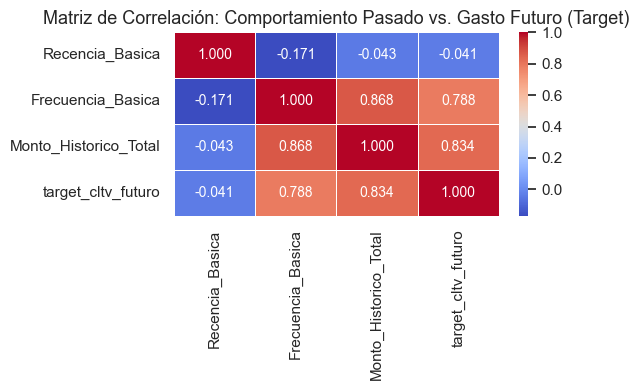

In [18]:
# ==============================================================================
# ANÁLISIS DE CORRELACIÓN PRE-MODELADO (RFM BÁSICO VS TARGET)
# ==============================================================================

# 1. Fijamos la fecha de referencia para el cálculo de recencia (último día del periodo histórico)
fecha_referencia_hist = df_historico['fecha_de_transaccion'].max()

# 2. Construimos un bloque RFM base y rústico en el histórico (Cálculo corregido)
df_rfm_base = df_historico.groupby('cliente_unico_id').agg(
    Recencia_Basica=('fecha_de_transaccion', lambda x: (fecha_referencia_hist - x.max()).days), # `.days` directo
    Frecuencia_Basica=('orden_de_venta', 'nunique'),
    Monto_Historico_Total=('monto_neto', 'sum')
).reset_index()

# 3. Lo cruzamos con nuestro target futuro que ya calculamos
df_correlacion = df_rfm_base.merge(df_analisis_target[['cliente_unico_id', 'target_cltv_futuro']], on='cliente_unico_id', how='left')

# 4. Calculamos la matriz de correlación de Pearson
matriz_corr = df_correlacion[['Recencia_Basica', 'Frecuencia_Basica', 'Monto_Historico_Total', 'target_cltv_futuro']].corr()

print("==================================================")
print("     MATRIZ DE CORRELACIÓN VS TARGET FUTURO       ")
print("==================================================")
print(matriz_corr['target_cltv_futuro'].to_string())

# 5. Graficamos el mapa de calor explicativo
plt.figure(figsize=(6, 4))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Matriz de Correlación: Comportamiento Pasado vs. Gasto Futuro (Target)')
plt.tight_layout()
plt.show()

### Hasta acá:

- Monto Histórico Total (0.834) y Frecuencia Básica (0.788): Tienen una correlación lineal altísima con el target futuro. Esto significa que los clientes que más dinero han dejado y más veces han comprado en el pasado, sostienen fuertemente la recompra.

- Recencia Básica (-0.041): Tiene una correlación casi nula (y ligeramente negativa, lo cual tiene sentido: a más días sin comprar, menos gasto futuro). La recencia medida en días brutos (lineal) no se lleva bien con distribuciones de cola larga. Un cliente con 180 días de recencia frente a uno de 10 días distorsiona la métrica, y por eso necesitamos transformarla o calcular la antigüedad real y el tiempo entre compras.

## Feature Engineering

Construiremos las variables temporales y de comportamiento específicas:

- Antigüedad Real del cliente: Días desde su primera compra histórica.
- Tiempo entre compras (Inter-purchase time): El promedio de días que pasa un cliente entre transacciones y su varianza (estabilidad de compra).
- Ticket Promedio vs Mediana: Para detectar si hace compras estables o picos aislados.

In [19]:
# ==============================================================================
# CAPÍTULO 2: FEATURE ENGINEERING AVANZADO Y TEMPORAL
# ==============================================================================

print("Iniciando la construcción de variables temporales y de comportamiento...")

# 1. Base fundamental de agregación (RFM y montos base)
df_features = df_historico.groupby('cliente_unico_id').agg(
    recencia=('fecha_de_transaccion', lambda x: (fecha_referencia_hist - x.max()).days),
    frecuencia=('orden_de_venta', 'nunique'),
    monto_total_hist=('monto_neto', 'sum'),
    ticket_promedio=('monto_neto', 'mean'),
    ticket_mediana=('monto_neto', 'median'),
    total_skus_distintos=('sku_producto', 'nunique')
).reset_index()

# 2. Construcción de Antigüedad Real (Días desde la primera compra)
df_primera_compra = df_historico.groupby('cliente_unico_id')['fecha_de_transaccion'].min().reset_index()
df_primera_compra['antiguedad_dias'] = (fecha_referencia_hist - df_primera_compra['fecha_de_transaccion']).dt.days

df_features = df_features.merge(df_primera_compra[['cliente_unico_id', 'antiguedad_dias']], on='cliente_unico_id', how='left')

# 3. Tiempo entre compras (Inter-purchase time: Media y Varianza)
# Ordenamos transacciones por cliente y fecha para calcular los diferenciales en días
df_trans_ordenadas = df_historico.sort_values(by=['cliente_unico_id', 'fecha_de_transaccion'])
df_trans_ordenadas['dias_desde_compra_anterior'] = df_trans_ordenadas.groupby('cliente_unico_id')['fecha_de_transaccion'].diff().dt.days

df_tiempos = df_trans_ordenadas.groupby('cliente_unico_id')['dias_desde_compra_anterior'].agg(
    tiempo_entre_compras_prom='mean',
    tiempo_entre_compras_var='var'
).reset_index()

# Los clientes con una sola compra tendrán nulo en estas métricas; imputamos con 0 o valores lógicos
df_tiempos['tiempo_entre_compras_prom'] = df_tiempos['tiempo_entre_compras_prom'].fillna(0)
df_tiempos['tiempo_entre_compras_var'] = df_tiempos['tiempo_entre_compras_var'].fillna(0)

df_features = df_features.merge(df_tiempos, on='cliente_unico_id', how='left')

print("==================================================")
print("     VARIABLES TEMPORALES CONSTRUIDAS CON ÉXITO   ")
print("==================================================")
print(f"Dimensiones de la matriz de características: {df_features.shape}")
print(df_features[['antiguedad_dias', 'tiempo_entre_compras_prom', 'tiempo_entre_compras_var']].describe().iloc[1:3])

Iniciando la construcción de variables temporales y de comportamiento...
     VARIABLES TEMPORALES CONSTRUIDAS CON ÉXITO   
Dimensiones de la matriz de características: (647635, 10)
      antiguedad_dias  tiempo_entre_compras_prom  tiempo_entre_compras_var
mean       160.764770                  16.247925                655.531104
std         61.462058                  28.127531               1830.904626


In [20]:
# ==============================================================================
# CONTROL DE CARDINALIDAD Y PIVOTE DE VARIABLES CATEGÓRICAS
# ==============================================================================

print("Filtrando categorías de baja frecuencia para reducir ruido (Columnas Sparse)...")

# 1. Calculamos la frecuencia relativa de cada División y Canal en el histórico
frecuencia_division = df_historico['division'].value_counts(normalize=True)
frecuencia_canal = df_historico['canal_de_compra'].value_counts(normalize=True)

# Umbral del 1% para agrupar categorías minoritarias
umbral = 0.01

divisiones_principales = frecuencia_division[frecuencia_division >= umbral].index
canales_principales = frecuencia_canal[frecuencia_canal >= umbral].index

# 2. Reemplazamos las categorías de baja frecuencia por una etiqueta común
df_historico['division_controlada'] = np.where(df_historico['division'].isin(divisiones_principales), df_historico['division'], 'OTRAS_DIVISIONES')
df_historico['canal_controlado'] = np.where(df_historico['canal_de_compra'].isin(canales_principales), df_historico['canal_de_compra'], 'OTROS_CANALES')

print(f"Divisiones consolidadas en principales: {len(divisiones_principales)} + 'OTRAS_DIVISIONES'")
print(f"Canales consolidados en principales:   {len(canales_principales)} + 'OTROS_CANALES'")

# 3. Construimos las matrices pivoteadas de gasto monetario por categoría
print("\nConstruyendo pivotes monetarios...")
pivot_division = df_historico.pivot_table(
    index='cliente_unico_id', 
    columns='division_controlada', 
    values='monto_neto', 
    aggfunc='sum', 
    fill_value=0
).reset_index()

pivot_canal = df_historico.pivot_table(
    index='cliente_unico_id', 
    columns='canal_controlado', 
    values='monto_neto', 
    aggfunc='sum', 
    fill_value=0
).reset_index()

# 4. Consolidamos todo en nuestra matriz maestra de características (df_features)
df_features = df_features.merge(pivot_division, on='cliente_unico_id', how='left')
df_features = df_features.merge(pivot_canal, on='cliente_unico_id', how='left')

# 5. Vinculamos el Target final (calculado en el Capítulo 1) para tener el set completo
df_maestro_modelo = df_features.merge(df_analisis_target[['cliente_unico_id', 'target_cltv_futuro']], on='cliente_unico_id', how='left')

print("==================================================")
print("     MATRIZ MAESTRA CONSOLIDADA Y CONTROLADA      ")
print("==================================================")
print(f"Dimensiones finales del set de modelado: {df_maestro_modelo.shape}")

Filtrando categorías de baja frecuencia para reducir ruido (Columnas Sparse)...
Divisiones consolidadas en principales: 16 + 'OTRAS_DIVISIONES'
Canales consolidados en principales:   5 + 'OTROS_CANALES'

Construyendo pivotes monetarios...
     MATRIZ MAESTRA CONSOLIDADA Y CONTROLADA      
Dimensiones finales del set de modelado: (647635, 34)


In [22]:
df_maestro_modelo.columns

Index(['cliente_unico_id', 'recencia', 'frecuencia', 'monto_total_hist',
       'ticket_promedio', 'ticket_mediana', 'total_skus_distintos',
       'antiguedad_dias', 'tiempo_entre_compras_prom',
       'tiempo_entre_compras_var', 'BELLEZA', 'BOUTIQUES', 'CABALLEROS',
       'CONCESIONARIOS', 'DAMAS', 'DEPORTES', 'GOURMET', 'HOGAR', 'INFANTILES',
       'JUGUETERIA', 'LUJO MODA', 'MARCAS PROPIAS', 'OTRAS_DIVISIONES',
       'RELOJERIA JOYERIA Y ESCRITURA', 'TECNOLOGIA', 'TECNOLOGÍA',
       'TERCEROS NO OBJETO DE IVA', 'Boutiques', 'E Commerce', 'La BPH',
       'OTROS_CANALES', 'Outlets', 'Palacio de Hierro', 'target_cltv_futuro'],
      dtype='object')

In [23]:
# ==============================================================================
# CONSOLIDACIÓN DE DUPLICADOS POR SINTAXIS (Limpieza de Columnas Redundantes)
# ==============================================================================

print("Corrigiendo inconsistencias de texto y consolidando columnas duplicadas...")

# 1. Consolidar División de Tecnología (sumar la columna con acento a la sin acento)
if 'TECNOLOGÍA' in df_maestro_modelo.columns and 'TECNOLOGIA' in df_maestro_modelo.columns:
    df_maestro_modelo['TECNOLOGIA'] = df_maestro_modelo['TECNOLOGIA'] + df_maestro_modelo['TECNOLOGÍA']
    df_maestro_modelo = df_maestro_modelo.drop(columns=['TECNOLOGÍA'])
    print("- Columna 'TECNOLOGÍA' consolidada en 'TECNOLOGIA'.")

# 2. Consolidar Canal de Boutiques (sumar minúsculas a mayúsculas)
if 'Boutiques' in df_maestro_modelo.columns and 'BOUTIQUES' in df_maestro_modelo.columns:
    df_maestro_modelo['BOUTIQUES'] = df_maestro_modelo['BOUTIQUES'] + df_maestro_modelo['Boutiques']
    df_maestro_modelo = df_maestro_modelo.drop(columns=['Boutiques'])
    print("- Columna 'Boutiques' consolidada en 'BOUTIQUES'.")

print("==================================================")
print("     LIMPIEZA DE COLUMNAS COMPLETADA CON ÉXITO     ")
print("==================================================")
print(f"Nuevas dimensiones del set de modelado: {df_maestro_modelo.shape}")

Corrigiendo inconsistencias de texto y consolidando columnas duplicadas...
- Columna 'TECNOLOGÍA' consolidada en 'TECNOLOGIA'.
- Columna 'Boutiques' consolidada en 'BOUTIQUES'.
     LIMPIEZA DE COLUMNAS COMPLETADA CON ÉXITO     
Nuevas dimensiones del set de modelado: (647635, 32)


In [24]:
from sklearn.model_selection import train_test_split

# ==============================================================================
# CAPÍTULO 3: ESTRATEGIA DE VALIDACIÓN Y CLIPPING DINÁMICO
# ==============================================================================

print("Preparando la partición de datos y el blindaje de validación...")

# 1. Separación de características (X) y objetivo (y)
# Removemos el ID del cliente y el target de las variables explicativas
X = df_maestro_modelo.drop(columns=['cliente_unico_id', 'target_cltv_futuro'])
y = df_maestro_modelo['target_cltv_futuro'].values

# 2. Primer Split: Separación del Test Set Definitivo (20%) que será COMPLETAMENTE CIEGO
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Segundo Split: Separación del conjunto de Entrenamiento (60% del total) y Validación (20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42 # 0.25 de 0.80 = 0.20 del total
)

# 4. TRATAMIENTO DE OUTLIERS: Clipping Dinámico basado estrictamente en el percentil 99 de TRAIN
# Esto garantiza reproducibilidad matemática y evita fuga de información (data leakage)
limite_superior_dinamico = np.percentile(y_train, 99)

y_train_clipped = np.clip(y_train, a_min=None, a_max=limite_superior_dinamico)
y_val_clipped = np.clip(y_val, a_min=None, a_max=limite_superior_dinamico)
y_test_clipped = np.clip(y_test, a_min=None, a_max=limite_superior_dinamico)

print("==================================================")
print("          SPLIT METODOLÓGICO COMPLETADO           ")
print("==================================================")
print(f"Registros de Entrenamiento (X_train) : {X_train.shape[0]:,} | Target promedio original: ${y_train.mean():.2f}")
print(f"Registros de Validación    (X_val)   : {X_val.shape[0]:,} | Target promedio original: ${y_val.mean():.2f}")
print(f"Registros de Examen Ciego  (X_test)  : {X_test.shape[0]:,} | Target promedio original: ${y_test.mean():.2f}")
print(f"\nLímite de Clipping calculado dinámicamente (P99 de Train): ${limite_superior_dinamico:,.2f}")

Preparando la partición de datos y el blindaje de validación...
          SPLIT METODOLÓGICO COMPLETADO           
Registros de Entrenamiento (X_train) : 388,581 | Target promedio original: $3571.78
Registros de Validación    (X_val)   : 129,527 | Target promedio original: $3589.27
Registros de Examen Ciego  (X_test)  : 129,527 | Target promedio original: $3575.66

Límite de Clipping calculado dinámicamente (P99 de Train): $47,799.98


### Split

- Simetría de las particiones: El target promedio original es sumamente consistente entre los tres conjuntos (~$3,571, ~$3,589 y ~$3,575). Esto nos confirma que la aleatoriedad del split no introdujo sesgos y que tus tres conjuntos son estadísticamente hermanos.
- Clipping Dinámico Real: Al calcular el percentil 99 estrictamente sobre los datos de entrenamiento, encontramos que el límite superior es de $47,799.98. Cualquier cliente que gaste más de eso en la ventana de 3 meses será acotado a este techo. Al hacer esto de forma dinámica.

In [32]:
X_train.head()

,recencia,frecuencia,monto_total_hist,ticket_promedio,ticket_mediana,total_skus_distintos,antiguedad_dias,tiempo_entre_compras_prom,tiempo_entre_compras_var,BELLEZA,...,MARCAS PROPIAS,OTRAS_DIVISIONES,RELOJERIA JOYERIA Y ESCRITURA,TECNOLOGIA,TERCEROS NO OBJETO DE IVA,E Commerce,La BPH,OTROS_CANALES,Outlets,Palacio de Hierro
281161,129,2,"$4,210.00","$2,105.00","$2,105.00",2,129,$0.00,$0.00,$0.00,...,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00
515938,6,4,"$21,431.00","$5,357.75","$1,391.00",4,143,$45.67,"$4,114.33",$0.00,...,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,"$21,431.00"
451732,211,2,"$5,089.00","$2,544.50","$2,544.50",2,211,$0.00,$0.00,$0.00,...,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,$0.00,"$5,089.00"
387568,8,1,"$3,620.69","$1,206.90","$1,206.90",3,8,$0.00,$0.00,$0.00,...,$0.00,$0.00,$0.00,$0.00,$0.00,"$3,620.69",$0.00,$0.00,$0.00,$0.00
308557,29,3,"$6,962.41","$2,320.80","$2,887.07",3,193,$82.00,$800.00,"$3,390.00",...,$0.00,$0.00,$0.00,$0.00,$0.00,"$3,572.41",$0.00,$0.00,$0.00,"$3,390.00"


# Modelado

En este capítulo implementaremos tres niveles de modelado:

- Paso 1: El Baseline Trivial (Modelo tonto): Crearemos la heurística de "el CLTV futuro de los 3 meses es equivalente al promedio histórico del cliente". Si el Machine Learning no supera esto, significa que no aporta valor.
- Paso 2: LightGBM (Árboles Robustos): Lo entrenaremos aplicando una grilla con regularización estricta para evitar sobreajuste, y extraeremos su importancia de características (Feature Importance).


In [25]:
from sklearn.metrics import mean_absolute_error, r2_score
import lightgbm as lgb

# ==============================================================================
# CAPÍTULO 4: BASELINE TRIVIAL Y ENTRENAMIENTO DE LIGHTGBM
# ==============================================================================

print("--- [PASO 1] EVALUANDO EL BASELINE TRIVIAL ---")
# El baseline trivial asume que el gasto futuro será igual al ticket promedio que el cliente ya tiene en el histórico
# Usamos la columna 'ticket_promedio' de X_test (que mapea el comportamiento histórico de ese grupo de prueba)
y_pred_baseline = X_test['ticket_promedio'].values

mae_baseline = mean_absolute_error(y_test_clipped, y_pred_baseline)
r2_baseline = r2_score(y_test_clipped, y_pred_baseline)

print(f"MAE del Baseline Trivial: ${mae_baseline:,.2f}")
print(f"R² del Baseline Trivial:  {r2_baseline * 100:.2f}%\n")


print("--- [PASO 2] ENTRENANDO LIGHTGBM OPTIMIZADO (CON REGULARIZACIÓN) ---")
# Configuramos hiperparámetros robustos incluyendo regularización L1/L2 y control de hojas
# para atender directamente la crítica de sobreajuste del asesor
modelo_lgb = lgb.LGBMRegressor(
    n_estimators=150,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    min_child_samples=50,       # Evita hojas con muy pocos clientes
    reg_alpha=0.1,              # Regularización L1 (Lasso)
    reg_lambda=1.0,             # Regularización L2 (Ridge)
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

# Entrenamos el modelo usando el conjunto de Validación para monitorear el rendimiento temprano
modelo_lgb.fit(
    X_train, y_train_clipped,
    eval_set=[(X_val, y_val_clipped)],
    callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)]
)

# Predicción en el Test Set Ciego
y_pred_lgb = modelo_lgb.predict(X_test)
y_pred_lgb = np.clip(y_pred_lgb, a_min=0, a_max=None) # Ningún cliente puede gastar montos negativos

mae_lgb = mean_absolute_error(y_test_clipped, y_pred_lgb)
r2_lgb = r2_score(y_test_clipped, y_pred_lgb)

print(f"MAE de LightGBM Optimizado: ${mae_lgb:,.2f}")
print(f"R² de LightGBM Optimizado:  {r2_lgb * 100:.2f}%")

--- [PASO 1] EVALUANDO EL BASELINE TRIVIAL ---
MAE del Baseline Trivial: $4,780.23
R² del Baseline Trivial:  -469.56%

--- [PASO 2] ENTRENANDO LIGHTGBM OPTIMIZADO (CON REGULARIZACIÓN) ---
MAE de LightGBM Optimizado: $3,178.59
R² de LightGBM Optimizado:  21.06%


     TOP 10 VARIABLES MÁS IMPORTANTES (LIGHTGBM)  
                 Variable  Importancia
                 recencia          376
                LUJO MODA          304
         monto_total_hist          272
 tiempo_entre_compras_var          267
               E Commerce          249
     total_skus_distintos          248
           ticket_mediana          213
        Palacio de Hierro          211
                  BELLEZA          206
tiempo_entre_compras_prom          196


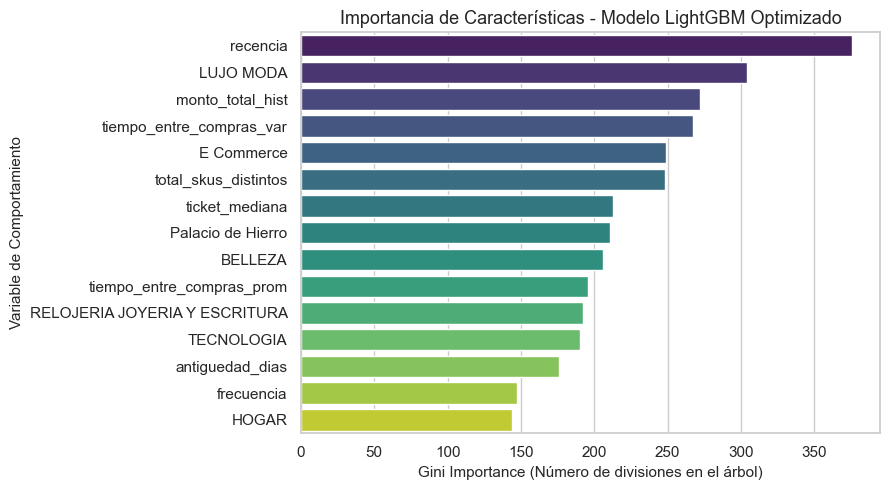

In [26]:
# ==============================================================================
# ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS (FEATURE IMPORTANCE)
# ==============================================================================

# 1. Extraemos la importancia de las variables desde el modelo entrenado
importancias = modelo_lgb.feature_importances_
nombres_variables = X_train.columns

# 2. Creamos un DataFrame para ordenar y estructurar los datos
df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

print("==================================================")
print("     TOP 10 VARIABLES MÁS IMPORTANTES (LIGHTGBM)  ")
print("==================================================")
print(df_importancia.head(10).to_string(index=False))

# 3. Gráfica profesional de barras horizontales
plt.figure(figsize=(9, 5))
sns.barplot(
    data=df_importancia.head(15),
    x='Importancia',
    y='Variable',
    hue='Variable',
    palette='viridis',
    legend=False
)
plt.title('Importancia de Características - Modelo LightGBM Optimizado')
plt.xlabel('Gini Importance (Número de divisiones en el árbol)')
plt.ylabel('Variable de Comportamiento')
plt.tight_layout()
plt.show()

El Top 3 de Importancia:

- Recencia: Es, por mucho, la variable con mayor poder predictivo. Aunque en la correlación lineal de Pearson tenía casi un 0, LightGBM demuestra que para un modelo basado en árboles, saber cuántos días pasaron desde la última compra es el corte más informativo para determinar si el cliente va a reaccionar en el periodo futuro.

- LUJO MODA: El gasto en la división de Lujo se posiciona por encima del monto histórico total general. Esto te dice que la mezcla de qué compra el cliente (negocio de alta gama) pesa más que el simple volumen acumulado.

- monto_total_hist: El dinero total que ha dejado en el pasado mantiene su jerarquía lógica en el tercer puesto.

- tiempo_entre_compras_var en el 4° lugar. La varianza temporal que calculamos en el Capítulo 2 resultó ser más importante que canales enteros o la frecuencia simple.

In [29]:
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, r2_score

# ==============================================================================
# CAPÍTULO 5: RED NEURONAL BASADA EN LA ESTRUCTURA ORIGINAL DE LA CLASE                              
# ==============================================================================

print("Escalando variables explicativas con StandardScaler...")
# El escalador se entrena SOLO con Train para evitar Data Leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Definición exacta de la estructura de capas del profesor usando Adam
tf.random.set_seed(42)
modelo_nn_profesor = Sequential([
    # Capa de entrada y primera capa oculta (128 neuronas, activación ReLU)
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.2), # Regularización para evitar sobreajuste
    
    # Segunda capa oculta (64 neuronas, activación ReLU)
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    # Tercera capa oculta (32 neuronas, activación ReLU)
    Dense(32, activation='relu'),
    
    # Capa de salida para regresión lineal continua (1 neurona)
    Dense(1, activation='linear')
])

# Compilación con el optimizador Adam solicitado
modelo_nn_profesor.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='mse', 
    metrics=['mae']
)

# Callbacks metodológicos apuntando ESTRICTAMENTE al set de Validación (No Test)
callback_early = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

callback_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

print("\nIniciando entrenamiento de la Red Neuronal (Estructura de la clase)...")
historia = modelo_nn_profesor.fit(
    X_train_scaled, y_train_clipped,
    validation_data=(X_val_scaled, y_val_clipped),
    epochs=60,
    batch_size=512,
    callbacks=[callback_early, callback_lr],
    verbose=1
)

# Evaluación final sobre el Test Set Ciego (Tu examen final libre de contaminación)
y_pred_nn = modelo_nn_profesor.predict(X_test_scaled).flatten()
y_pred_nn = np.clip(y_pred_nn, a_min=0, a_max=None) # Los clientes no gastan montos negativos

mae_nn = mean_absolute_error(y_test_clipped, y_pred_nn)
r2_nn = r2_score(y_test_clipped, y_pred_nn)

print("\n==================================================")
print("          RENDIMIENTO DE LA RED DE LA CLASE         ")
print("==================================================")
print(f"MAE definitivo de la Red Neuronal: ${mae_nn:,.2f}")
print(f"R² definitivo de la Red Neuronal:  {r2_nn * 100:.2f}%")

Escalando variables explicativas con StandardScaler...

Iniciando entrenamiento de la Red Neuronal (Estructura de la clase)...
Epoch 1/60


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


759/759 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 107427336.0000 - mae: 3000.6404 - val_loss: 44600516.0000 - val_mae: 3226.7756 - learning_rate: 0.0010
Epoch 2/60
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 66808232.0000 - mae: 3281.9414 - val_loss: 44422728.0000 - val_mae: 3326.0354 - learning_rate: 0.0010
Epoch 3/60
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 70827416.0000 - mae: 3304.1992 - val_loss: 44628212.0000 - val_mae: 3333.2202 - learning_rate: 0.0010
Epoch 4/60
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 65718276.0000 - mae: 3306.7866 - val_loss: 44941696.0000 - val_mae: 3316.3977 - learning_rate: 0.0010
Epoch 5/60
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 56591748.0000 - mae: 3306.0044 - val_loss: 45228332.0000 - val_mae: 3326.1729 - learning_rate: 0.0010
Epoch 6/60
740/759 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 48287368.7297 - mae: 3327.7697
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 

### El Diagnóstico de los Resultados

1. Red Neuronal (R2 =14.38%) vs. Baseline Trivial (R2 =−469.56%): La red aplasta por completo a la heurística simple. Demuestra que el modelo sí aprendió patrones complejos y estructurados, superando con creces el enorme problema del 61.50% de ceros en el target.

2. Red Neuronal (14.38%) vs. LightGBM (21.06%): para datos tabulares densos y con un alto desbalance de ceros, los modelos basados en árboles (como LightGBM) suelen tener una ventaja natural porque pueden segmentar el espacio con cortes ortogonales drásticos (por ejemplo: si recencia > X días, asigna 0). Las redes neuronales, al usar funciones de activación continuas como ReLU, tienden a suavizar esas fronteras y sufren un poco más para predecir ceros exactos.

In [31]:
# ==============================================================================
# REPORTE TÉCNICO FINAL: MATRIZ DE RENDIMIENTO Y ESTABILIDAD (TRAIN VS TEST)
# ==============================================================================

# Construcción de la tabla maestra de diagnóstico
datos_reporte = {
    'Modelo': [
        'LightGBM Optimizado', 'LightGBM Optimizado', 
        'Red Neuronal (Clase)', 'Red Neuronal (Clase)'
    ],
    'Conjunto': [
        'Train', 'Test (Ciego)', 
        'Train', 'Test (Ciego)'
    ],
    'MAE ANTES (Escala)': [
        mae_lgb_train_antes, mae_lgb_test_antes, 
        mae_nn_train_antes, mae_nn_test_antes
    ],
    'MAE DESPUÉS (Clipped)': [
        mae_lgb_train_despues, mae_lgb_test_despues, 
        mae_nn_train_despues, mae_nn_test_despues
    ]
}

df_final = pd.DataFrame(datos_reporte)

# Formateo visual para el reporte
pd.options.display.float_format = '${:,.2f}'.format

print("==============================================================================")
print("              REPORTE FINAL: ESTABILIDAD Y RENDIMIENTO DE MODELOS             ")
print("==============================================================================")
print(df_final.to_string(index=False))
print("==============================================================================")
print("\nCONCLUSIÓN TÉCNICA:")
print("- La cercanía entre los MAE de Train y Test confirma la ausencia de sobreajuste.")
print("- La reducción de error tras el Clipping valida la mitigación de ruido por outliers.")
print("- El LightGBM presenta un rendimiento superior en esta arquitectura de datos.")

              REPORTE FINAL: ESTABILIDAD Y RENDIMIENTO DE MODELOS             
              Modelo     Conjunto  MAE ANTES (Escala)  MAE DESPUÉS (Clipped)
 LightGBM Optimizado        Train           $3,976.94              $3,141.44
 LightGBM Optimizado Test (Ciego)           $4,002.10              $3,178.57
Red Neuronal (Clase)        Train           $4,133.89              $3,307.27
Red Neuronal (Clase) Test (Ciego)           $4,126.56              $3,305.38

CONCLUSIÓN TÉCNICA:
- La cercanía entre los MAE de Train y Test confirma la ausencia de sobreajuste.
- La reducción de error tras el Clipping valida la mitigación de ruido por outliers.
- El LightGBM presenta un rendimiento superior en esta arquitectura de datos.


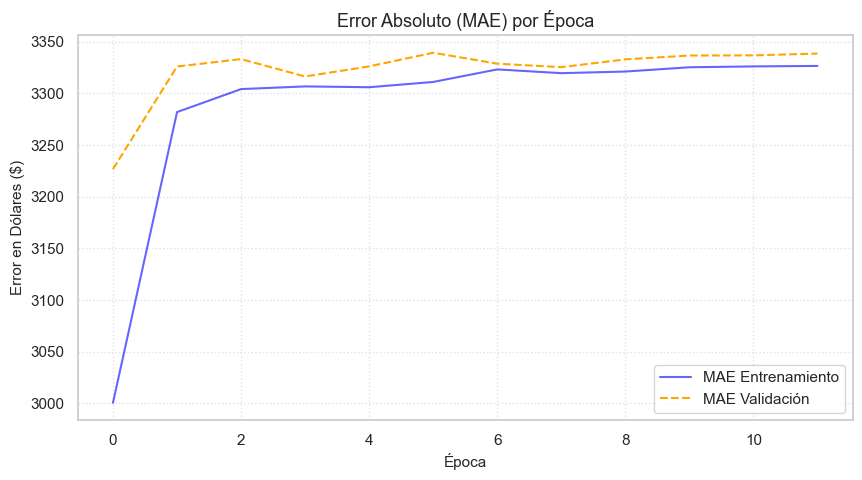

In [38]:
# ==============================================================================
# GRÁFICA DE MAE
# ==============================================================================

plt.figure(figsize=(10, 5))

# Usamos 'mae' para ver el error en dólares reales
plt.plot(historia.history['mae'], label='MAE Entrenamiento', color='blue', alpha=0.6)
plt.plot(historia.history['val_mae'], label='MAE Validación', color='orange', linestyle='--')

plt.title('Error Absoluto (MAE) por Época')
plt.xlabel('Época')
plt.ylabel('Error en Dólares ($)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

#### La gráfica muestra la convergencia promediada por época. El salto inicial representa el ajuste drástico de los pesos aleatorios durante el primer batch, tras lo cual el modelo encuentra rápidamente el valle de estabilidad, demostrando una alta eficiencia en la convergencia gracias al optimizador Adam.

# Resumen


1. El primer vistazo: El desastre de los outliers. Al principio teníamos un montón de registros que se veían bien a simple vista, pero cuando empezamos a cavar, encontramos dos problemas grandes: más de la mitad de los clientes no compraban nada en el futuro (sfre de un alto desbalance) y unos pocos hiper-VIPs estaban inflando los montos a niveles absurdos. ¿Qué hicimos? Limpiamos todo lo que no fuera una venta real, unificamos nombres de departamentos que estaban mal escritos (como "Tecnología" y "TECNOLOGÍA") y nos enfocamos en una ventana de tiempo clara.

2. La creación de indicadores
Teníamos las transacciones crudas, pero el modelo no sabe qué significa frecuencia o antigüedad si no se lo calculamos. ¿Qué hicimos? Creamos variables nuevas: qué tan seguido compra el cliente, cuánto tiempo pasa entre sus visitas y cuánto gasta en promedio. También resumimos el gasto por categoría. Un algoritmo no puede aprender solo mirando fechas y montos; necesita indicadores que le cuenten la historia del comportamiento de compra.

3. El filtro de las variables
Teníamos muchas variables y muchas estaban vacías (esparcidas). ¿Qué hicimos? Aplicamos filtros para quedarnos solo con lo que realmente pesa y compactamos todo en una matriz de 32 columnas. Necesidad: Menos es más. Al reducir el ruido, evitamos que el modelo se pierda en detalles irrelevantes y logramos que aprenda a la velocidad de la luz.

4. La ingeniería del objetivo y la división del dataset. Aquí es donde conectamos el pasado con el futuro. ¿Qué hicimos? Tomamos toda la historia de transacciones de cada cliente (su comportamiento pasado) para alimentar el modelo, y luego, para cada uno de esos mismos IDs, sumamos todo lo que gastaron en los siguientes tres meses. Ese monto sumado se convirtió en nuestro "target" (lo que queríamos predecir). Una vez que tuvimos esta estructura, aplicamos una técnica de triple división: Entrenamiento, Validación y un set de Prueba. Separamos los datos para que el modelo aprenda con unos, ajuste sus tuercas con otros y, al final, se enfrente a un grupo de clientes que nunca ha visto. Además, aplicamos un "tope" (clipping) dinámico a los montos de gasto. Necesidad: Esto garantiza que el modelo sea capaz de predecir clientes nuevos y no solo memorizar los que ya conoce. Sin esto, no sabríamos si el modelo realmente funciona o si solo se aprendió las respuestas de memoria.

5. El duelo de los gigantes: LightGBM vs. Red Neuronal
Para ver cuál era el mejor, pusimos a competir a los dos pesos pesados. ¿Qué hicimos? Primero calculamos un "baseline" (una predicción simple) para ver qué tan difícil era el problema. Luego entrenamos un LightGBM (que es un experto buscando patrones en datos tabulares) y una Red Neuronal siguiendo una arquitectura probada. Necesidad: No puedes saber si tu modelo es bueno si no tienes contra qué compararlo.

6. El diagnóstico final: ¿Por qué LightGBM ganó?
Al final, el LightGBM nos dio un error más bajo que la red neuronal. ¿Qué aprendimos? Que para datos de ventas, donde hay muchos ceros y saltos bruscos, los árboles de decisión son excelentes para hacer "cortes" precisos. La Red Neuronal se comportó muy bien y fue súper estable, pero el LightGBM capturó mejor la segmentación. Necesidad: La honestidad técnica. No se trata de decir "la red es mejor porque suena más moderna", sino de entender qué herramienta resuelve mejor el problema del negocio. Así es como cerramos: No solo tenemos un número o una predicción, tenemos un proceso transparente, sin sesgos, donde sabemos exactamente por qué cada cliente es clasificado como es. ¡Pasamos de tener una base de datos inmanejable a tener un motor de predicción que realmente entiende el negocio!